## Compare ind. networks between Dyscalculics & Controls

1. network sizes 
    - whole brain
    - NPC - L/R
    

In [12]:
import numpy as np
import pandas as pd
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns
import os.path as op

bids_folder ='/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
#grad_folder = op.join(bids_folder, 'derivatives', 'gradients.36Pscrub3BPfilterrunFD104')
net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full_01')

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

subList = [f'{sub:02d}' for sub in range(1, 67)]
group_assignment = pd.read_csv(op.join(bids_folder, 'group_assignment.csv')).set_index('subject')

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


In [ ]:
nets_all = []
df_nets = pd.DataFrame(columns=[f'net_{x}' for x in range(2, 10)], index=range(1, 67))
subs = []
for sub in subList:
    try:
        nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
        nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
        nets_fsav5[mask] = nets
        nets_all.append(nets_fsav5)

        net_i, counts = np.unique(nets, return_counts=True)

        for net, count in zip(net_i, counts):
            df_nets.loc[int(sub), f'net_{net}'] = count

        subs.append(int(sub))
    except Exception as e:
        print(f'Error processing sub-{sub}: {e}')

df_nets = pd.DataFrame(nets_all, index=subs)
df_nets.index.name = 'subject'
df_nets = df_nets.join(group_assignment).set_index(['group'], append=True)

In [34]:
from utils import get_NPC_mask

npc_mask = get_NPC_mask(space='fsaverage5')

In [38]:
df_nets = pd.DataFrame(columns=[f'net_{x}' for x in range(2, 10)], index=range(1, 67))
df_nets.index.name = 'subject'
df_nets = df_nets.join(group_assignment).set_index(['group'], append=True)

only_NPC = True
for sub in subList:
    try:
        nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
        if only_NPC:
            nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
            nets_fsav5[mask] = nets
            nets = nets_fsav5[npc_mask]
        net_i, counts = np.unique(nets, return_counts=True)

        for net, count in zip(net_i, counts):
            df_nets.loc[int(sub), f'net_{int(net)}'] = count

    except Exception as e:
        print(f'Error processing sub-{sub}: {e}')


Error processing sub-02: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full_01/sub-02_consensusMapping_confspec-36Pscrub3BPfilter.npy'
Error processing sub-05: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full_01/sub-05_consensusMapping_confspec-36Pscrub3BPfilter.npy'
Error processing sub-06: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full_01/sub-06_consensusMapping_confspec-36Pscrub3BPfilter.npy'
Error processing sub-41: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full_01/sub-41_consensusMapping_confspec-36Pscrub3BPfilter.npy'
Error processing sub-45: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networ

In [39]:
df_nets

,,net_2,net_3,net_4,net_5,net_6,net_7,net_8,net_9,net_-1
subject,group,,,,,,,,,
1,0,64,97,29,1239,NaN,58,NaN,23,NaN
2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,216,311,13,911,NaN,NaN,4,55,NaN
4,1,380,315,124,651,NaN,30,NaN,10,NaN
5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
62,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,0,86,405,189,810,NaN,NaN,NaN,20,NaN
64,0,195,508,16,769,NaN,NaN,4,18,NaN


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)

Text(0.5, 1.02, 'Group comparison: Network sizes \n NPC mask - True')

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


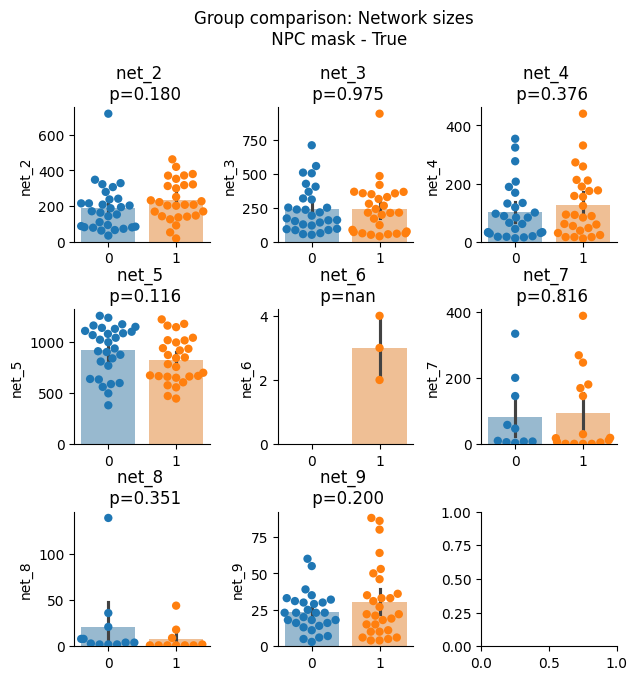

In [45]:
# between group test:
from scipy.stats import ttest_ind

figure, axes = plt.subplots(3, 3, figsize=(7,7))
axs = axes.flatten()
for i, net in enumerate(df_nets.columns[:8]):
    sns.barplot(data=df_nets.reset_index(), x='group', hue='group', y=net, alpha=0.5, legend=False, ax=axs[i])
    sns.swarmplot(data=df_nets.reset_index(), x='group', hue='group', y=net, size=6, legend=False, ax=axs[i])
    
    # Convert to numeric and drop NaNs manually
    group0_data = pd.to_numeric(df_nets.xs(0,0,'group')[net], errors='coerce').dropna()
    group1_data = pd.to_numeric(df_nets.xs(1,0,'group')[net], errors='coerce').dropna()
    
    stats = ttest_ind(group0_data, group1_data)

    axs[i].set(xlabel=None, title=f'{net} \n p={stats.pvalue:.3f}'   )
plt.subplots_adjust(hspace=0.5,wspace=0.5)
sns.despine()
figure.suptitle(f'Group comparison: Network sizes \n NPC mask - {only_NPC}', y=1.02)